Set up imports and directory to save model params

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import optuna
import jax
import jax.numpy as jnp
from flax import linen as nn
from flax.training import train_state
import optax
import flax.serialization
from jax import lax
import time

# drive.mount("/content/drive")

CKPT_DIR = "transformer_utils/char_transformer_ckpts"
os.makedirs(CKPT_DIR, exist_ok=True)

Load train and test files

In [ ]:
file_path_1 = 'data/text8_train.txt'
file_path_2 = 'data/text8_test.txt'

with open(file_path_1, "r") as f:
    text_train = f.read()

with open(file_path_2, "r") as f:
    text_test = f.read()

chars = list("abcdefghijklmnopqrstuvwxyz ")
vocab_size = len(chars)
print("Vocab size:", vocab_size)

stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}

def encode(s):
    """Encode string to array of integers"""
    ids = [stoi[c] for c in s]
    return np.array(ids, dtype=np.uint8)
def decode(arr): return "".join(itos[int(i)] for i in arr)


Vocab size: 27


Encode train, test and validation sets

In [ ]:
train_data_all = encode(text_train)
test_data      = encode(text_test)

N_train = train_data_all.shape[0]
print("Total training chars:", N_train)
print("Total test chars:", test_data.shape[0])

val_ratio = 0.125 
n_val = int(N_train * val_ratio)

train_int_array = train_data_all[:-n_val]
val_int_array   = train_data_all[-n_val:]

print("Train size:", train_int_array.shape[0])
print("Val size:  ", val_int_array.shape[0])
print("Test size: ", test_data.shape[0])


Total training chars: 90000000
Total test chars: 5000000
Train size: 78750000
Val size:   11250000
Test size:  5000000


Batching using jax

In [ ]:
def get_batch(data, rng, batch_size, block_size):
    max_start = data.shape[0] - (block_size + 1)

    starts = jax.random.randint(rng, (batch_size,), 0, max_start)

    def get_single(start):
        idxs = jnp.arange(block_size + 1) + start
        chunk = data[idxs]
        return chunk[:-1], chunk[1:]

    return jax.vmap(get_single)(starts)


Decoder only transformer

In [8]:

class CausalSelfAttention(nn.Module):
    d_model: int
    n_heads: int
    dropout_rate: float
    block_size: int
    @nn.compact
    def __call__(self, x, deterministic):
        B, T, C = x.shape
        head_dim = C // self.n_heads
        qkv = nn.Dense(3*C)(x).reshape(B, T, 3, self.n_heads, head_dim)
        q, k, v = qkv[:,:,0], qkv[:,:,1], qkv[:,:,2]
        q = jnp.transpose(q, (0,2,1,3))
        k = jnp.transpose(k, (0,2,1,3))
        v = jnp.transpose(v, (0,2,1,3))
        scale = 1.0 / jnp.sqrt(head_dim)
        att = jnp.einsum("bhqd,bhkd->bhqk", q, k) * scale
        mask = jnp.tril(jnp.ones((T,T), dtype=bool))
        att = jnp.where(mask, att, -1e10)
        att = nn.softmax(att, axis=-1)
        att = nn.Dropout(self.dropout_rate)(att, deterministic=deterministic)
        out = jnp.einsum("bhqk,bhkd->bhqd", att, v)
        out = jnp.transpose(out, (0,2,1,3)).reshape(B,T,C)
        out = nn.Dense(C)(out)
        return nn.Dropout(self.dropout_rate)(out, deterministic)


class FeedForward(nn.Module):
    d_model: int
    ffn_ratio: int
    dropout_rate: float
    @nn.compact
    def __call__(self, x, deterministic):
        h = nn.Dense(self.ffn_ratio*self.d_model)(x)
        h = nn.gelu(h)
        h = nn.Dense(self.d_model)(h)
        return nn.Dropout(self.dropout_rate)(h, deterministic)


class TransformerBlock(nn.Module):
    d_model: int
    n_heads: int
    ffn_ratio: int
    dropout_rate: float
    block_size: int
    @nn.compact
    def __call__(self, x, deterministic):
        h = nn.LayerNorm()(x)
        x = x + CausalSelfAttention(
            self.d_model, self.n_heads, self.dropout_rate, self.block_size
        )(h, deterministic)
        h = nn.LayerNorm()(x)
        x = x + FeedForward(self.d_model, self.ffn_ratio, self.dropout_rate)(h, deterministic)
        return x


class CharDecoderTransformer(nn.Module):
    vocab_size: int
    d_model: int
    n_layers: int
    n_heads: int
    ffn_ratio: int
    block_size: int
    dropout_rate: float
    @nn.compact
    def __call__(self, idx, deterministic=True):
        B,T = idx.shape
        tok = nn.Embed(self.vocab_size, self.d_model)(idx)
        pos = nn.Embed(self.block_size, self.d_model)(jnp.arange(T)[None])
        x = tok + pos
        x = nn.Dropout(self.dropout_rate)(x, deterministic)
        for _ in range(self.n_layers):
            x = TransformerBlock(
                self.d_model, self.n_heads, self.ffn_ratio,
                self.dropout_rate, self.block_size,
            )(x, deterministic)
        x = nn.LayerNorm()(x)
        return nn.Dense(self.vocab_size)(x)


LR scheduler

In [9]:
def build_lr_schedule(lr, warmup, total_steps):
    warmup = float(warmup)
    total_steps = float(total_steps)
    def schedule(step):
        step = jnp.array(step, dtype=jnp.float32)
        lr_warm = lr * (step / warmup)
        cos_progress = (step - warmup) / max(total_steps - warmup, 1)
        lr_cos = lr * 0.5 * (1 + jnp.cos(jnp.pi * cos_progress))
        return jnp.where(step < warmup, lr_warm, lr_cos)
    return schedule


Train state declaration

In [10]:
class TrainState(train_state.TrainState):
    pass

@jax.jit
def train_step(state, X, Y, rng):
    def loss_fn(params):
        logits = state.apply_fn({"params": params}, X, deterministic=False, rngs={"dropout": rng})
        return optax.softmax_cross_entropy_with_integer_labels(logits, Y).mean()
    loss, grads = jax.value_and_grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    return state, loss

@jax.jit
def eval_step(state, X, Y):
    logits = state.apply_fn({"params": state.params}, X, deterministic=True)
    return optax.softmax_cross_entropy_with_integer_labels(logits, Y).mean()


Functions to save and load model states

In [11]:
def save_ckpt(state, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "wb") as f:
        f.write(flax.serialization.to_bytes(state))
    print("[saved]", path)

def load_ckpt(state, path):
    with open(path, "rb") as f:
        data = f.read()
    print("[loaded]", path)
    return flax.serialization.from_bytes(state, data)


Val Loss Computation

In [ ]:
def compute_val_loss(state: TrainState, model: CharDecoderTransformer,
                     val_data: jnp.ndarray,
                     block_size: int,
                     batch_size: int,
                     rng) -> float:
    X, Y = get_batch(val_data, rng, batch_size, block_size)
    loss = eval_step(state, X, Y)
    return float(loss)


Objective function for Bayesian Optimization

In [ ]:
MAX_TRIAL_STEPS = 800   
TRIAL_EVAL_INTERVAL = 100  
TUNE_BATCH_SIZE = 32
VAL_BATCH_SIZE = 32

def objective(trial: optuna.trial.Trial):

    d_model    = trial.suggest_categorical("d_model",    [64, 128, 192, 256])
    n_layers   = trial.suggest_categorical("n_layers",   [4, 6, 8])
    ffn_ratio  = trial.suggest_categorical("ffn_ratio",  [2, 4])
    block_size = trial.suggest_categorical("block_size", [128, 192, 256])
    n_heads    = trial.suggest_categorical("n_heads",    [1, 2, 4])

    if d_model % n_heads != 0:
        raise optuna.exceptions.TrialPruned()
    head_dim = d_model // n_heads
    if head_dim < 16:
        raise optuna.exceptions.TrialPruned()

    lr          = trial.suggest_float("lr", 1e-5, 3e-3, log=True)
    warmup_steps= trial.suggest_int("warmup_steps", 50, 400)
    weight_decay= trial.suggest_float("weight_decay", 1e-8, 1e-3, log=True)
    dropout     = trial.suggest_float("dropout", 0.0, 0.4)
    grad_clip   = trial.suggest_float("grad_clip", 0.5, 5.0)

    model = CharDecoderTransformer(
        vocab_size=vocab_size,
        d_model=d_model,
        n_layers=n_layers,
        n_heads=n_heads,
        ffn_ratio=ffn_ratio,
        block_size=block_size,
        dropout_rate=dropout,
    )

    rng = jax.random.PRNGKey(0)
    params = model.init(rng, jnp.ones((1, block_size), dtype=jnp.int32))["params"]

    lr_schedule_fn = build_lr_schedule(lr, warmup_steps, MAX_TRIAL_STEPS)

    tx = optax.chain(
        optax.clip_by_global_norm(grad_clip),
        optax.adamw(
            learning_rate=lr_schedule_fn,
            weight_decay=weight_decay,
        ),
    )

    state = TrainState.create(
        apply_fn=model.apply,
        params=params,
        tx=tx,
    )

    rng_loop = rng
    best_val = float("inf")

    for step in range(1, MAX_TRIAL_STEPS + 1):
        rng_loop, key_b, key_l = jax.random.split(rng_loop, 3)

        X, Y = get_batch(train_int_array, key_b, TUNE_BATCH_SIZE, block_size)
        state, train_loss = train_step(state, X, Y, key_l)

        if step % TRIAL_EVAL_INTERVAL == 0:
            val_loss = compute_val_loss(
                state, model, val_int_array, block_size, VAL_BATCH_SIZE, rng_loop
            )
            best_val = min(best_val, val_loss)

            trial.report(val_loss, step)

            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    return best_val


Running the Bayesian Optimization to find optimal hyperparameters

In [ ]:
sampler = optuna.samplers.TPESampler(
    multivariate=True,
    group=True,
    n_startup_trials=5,
)

pruner = optuna.pruners.SuccessiveHalvingPruner(
    min_resource=TRIAL_EVAL_INTERVAL,  # first eval at 100 steps
    reduction_factor=4,
    min_early_stopping_rate=0,
)

study = optuna.create_study(
    direction="minimize",
    sampler=sampler,
    pruner=pruner,
)

study.optimize(objective, n_trials=75)  # adjust n_trials as you can afford

print("Best trial:", study.best_trial.number)
print("  Value:", study.best_trial.value)
print("  Params:", study.best_trial.params)
best_params = study.best_trial.params


[I 2025-11-18 15:27:35,542] A new study created in memory with name: no-name-a036dd0f-96b4-4b08-82f6-e00024778bdb
[I 2025-11-18 15:28:42,165] Trial 0 finished with value: 2.362492084503174 and parameters: {'d_model': 192, 'n_layers': 6, 'ffn_ratio': 2, 'block_size': 256, 'n_heads': 2, 'lr': 0.00020168969168286285, 'warmup_steps': 170, 'weight_decay': 2.1172775668251553e-07, 'dropout': 0.1343536452297434, 'grad_clip': 2.9380743697186134}. Best is trial 0 with value: 2.362492084503174.
[I 2025-11-18 15:29:46,851] Trial 1 finished with value: 2.345508098602295 and parameters: {'d_model': 256, 'n_layers': 4, 'ffn_ratio': 2, 'block_size': 256, 'n_heads': 4, 'lr': 0.000375366024965608, 'warmup_steps': 341, 'weight_decay': 1.9493996996033797e-07, 'dropout': 0.16757569538806294, 'grad_clip': 4.719768351074556}. Best is trial 1 with value: 2.345508098602295.
[I 2025-11-18 15:30:56,126] Trial 2 finished with value: 2.2052721977233887 and parameters: {'d_model': 128, 'n_layers': 8, 'ffn_ratio': 4

Best trial: 67
  Value: 1.530252456665039
  Params: {'d_model': 256, 'n_layers': 6, 'ffn_ratio': 4, 'block_size': 192, 'n_heads': 4, 'lr': 0.002734710475508506, 'warmup_steps': 161, 'weight_decay': 9.292977282504337e-08, 'dropout': 0.003484671519382993, 'grad_clip': 2.44940887078267}


Hyperparameters obtained from BO trials

In [ ]:
# Hyperparameters from BO trial
d_model      = 256
n_layers     = 6
ffn_ratio    = 4
block_size   = 192
n_heads      = 4
vocab_size = 27

learning_rate = 0.002734710475508506
weight_decay  = 9.292977282504337e-08
dropout_rate  = 0.003484671519382993
warmup_steps  = 161
grad_clip     = 2.44940887078267

FINAL_STEPS      = 75000
BATCH_SIZE       = 64
VAL_BATCH_SIZE   = 64
TEST_BATCH_SIZE  = 64
LOG_INTERVAL     = 200
PLOT_INTERVAL    = 2000

Model, optimizer and scheduler initialization

In [ ]:
rng = jax.random.PRNGKey(0)
model = CharDecoderTransformer(
    vocab_size=vocab_size,
    d_model=d_model,
    n_layers=n_layers,
    n_heads=n_heads,
    ffn_ratio=ffn_ratio,
    block_size=block_size,
    dropout_rate=dropout_rate,
)

params = model.init(rng, jnp.ones((1,block_size), dtype=jnp.int32))["params"]

lr_schedule = build_lr_schedule(learning_rate, warmup_steps, FINAL_STEPS)

tx = optax.chain(
    optax.clip_by_global_norm(grad_clip),
    optax.adamw(learning_rate=lr_schedule, weight_decay=weight_decay),
)

state = TrainState.create(apply_fn=model.apply, params=params, tx=tx)


Training loop 

In [ ]:
train_losses = []
val_losses = []
lrs = []

rng_loop = rng

for step in range(1, FINAL_STEPS+1):
    rng_loop, key_b, key_l = jax.random.split(rng_loop, 3)

    X, Y = get_batch(train_int_array, key_b, BATCH_SIZE, block_size)

    state, train_loss = train_step(state, X, Y, key_l)

    if step % LOG_INTERVAL == 0:
        lr_now = float(lr_schedule(step))
        Xv, Yv = get_batch(val_int_array, key_b, VAL_BATCH_SIZE, block_size)
        val_loss = float(eval_step(state, Xv, Yv))

        train_losses.append(float(train_loss))
        val_losses.append(val_loss)
        lrs.append(lr_now)

        print(f"step {step:6d} | train {float(train_loss):.4f} | val {val_loss:.4f} | lr {lr_now:.6e}")

    if step % 2000 == 0:
        save_ckpt(state, f"{CKPT_DIR}/step_{step}.msgpack")

save_ckpt(state, f"{CKPT_DIR}/state_final.msgpack")


step    200 | train 1.2181 | val 1.2699 | lr 2.734709e-03
step    400 | train 1.1911 | val 1.3191 | lr 2.734642e-03
step    600 | train 1.2507 | val 1.2028 | lr 2.734478e-03
step    800 | train 1.2008 | val 1.1887 | lr 2.734218e-03
step   1000 | train 1.2563 | val 1.2419 | lr 2.733862e-03
step   1200 | train 1.2052 | val 1.2421 | lr 2.733410e-03
step   1400 | train 1.2420 | val 1.2143 | lr 2.732861e-03
step   1600 | train 1.2081 | val 1.2491 | lr 2.732217e-03
step   1800 | train 1.2202 | val 1.2127 | lr 2.731475e-03
step   2000 | train 1.2069 | val 1.2064 | lr 2.730638e-03
[saved] /content/drive/MyDrive/char_transformer_ckpts/step_2000.msgpack
step   2200 | train 1.1975 | val 1.1658 | lr 2.729705e-03
step   2400 | train 1.2070 | val 1.1823 | lr 2.728675e-03
step   2600 | train 1.1722 | val 1.2094 | lr 2.727550e-03
step   2800 | train 1.1512 | val 1.1914 | lr 2.726329e-03
step   3000 | train 1.1516 | val 1.1881 | lr 2.725012e-03
step   3200 | train 1.1588 | val 1.1941 | lr 2.723599e-03


In [ ]:

rng = jax.random.PRNGKey(0)
dummy = jnp.zeros((1, block_size), dtype=jnp.int32)

model = CharDecoderTransformer(
    vocab_size=vocab_size,
    d_model=d_model,
    n_layers=n_layers,
    n_heads=n_heads,
    ffn_ratio=ffn_ratio,
    block_size=block_size,
    dropout_rate=dropout_rate,
)

params = model.init(rng, dummy)["params"]


schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=learning_rate,
    warmup_steps=warmup_steps,
    decay_steps=75000, 
    end_value=0.0,
)

tx = optax.chain(
    optax.clip_by_global_norm(grad_clip),
    optax.adamw(
        learning_rate=schedule,
        weight_decay=weight_decay,
    ),
)


In [ ]:
state = train_state.TrainState.create(
    apply_fn=model.apply,
    params=params,
    tx=tx,
)

Loading checkpoint from training

In [ ]:
CKPT_PATH = "transformer_utils/char_transformer_ckpts/state_final.msgpack"

with open(CKPT_PATH, "rb") as f:
    full_state_dict = flax.serialization.msgpack_restore(f.read())

restored_params = full_state_dict["params"]
print("✓ Params restored for inference!")


✓ Params restored for inference!


In [ ]:
def get_batch_eval(data, rng_key, batch_size, block_size):
    max_start = data.shape[0] - (block_size + 1)
    starts = jax.random.randint(rng_key, (batch_size,), 0, max_start)

    def get_single(start):
        chunk = jax.lax.dynamic_slice(data, (start,), (block_size + 1,))
        return chunk[:-1], chunk[1:]

    X, Y = jax.vmap(get_single)(starts)
    return X, Y


In [ ]:
def loss_and_acc(params, X, Y):
    logits = model.apply({"params": params}, X, deterministic=True)
    loss = optax.softmax_cross_entropy_with_integer_labels(logits, Y).mean()

    preds = jnp.argmax(logits, axis=-1)
    accuracy = (preds == Y).mean()

    return loss, accuracy


In [ ]:
@jax.jit
def eval_step_test(rng_key):
    X, Y = get_batch_eval(test_data, rng_key, 64, block_size)
    loss, acc = loss_and_acc(restored_params, X, Y)
    return loss, acc

Sanity check on test set

In [ ]:
N_EVAL_BATCHES = 500

rng = jax.random.PRNGKey(123)
losses = []
accs = []

for i in range(N_EVAL_BATCHES):
    rng, key = jax.random.split(rng)
    loss, acc = eval_step_test(key)
    losses.append(loss)
    accs.append(acc)

test_loss = float(jnp.mean(jnp.array(losses)))
test_acc  = float(jnp.mean(jnp.array(accs)))

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_acc:.4f}")
print(f"Perplexity    : {jnp.exp(test_loss):.2f}")


Test loss     : 1.0278
Test accuracy : 0.6793
Perplexity    : 2.79


In [ ]:
d_model      = 256
n_layers     = 6
ffn_ratio    = 4
block_size   = 192
n_heads      = 4
vocab_size   = 27

model = CharDecoderTransformer(
    vocab_size=vocab_size,
    d_model=d_model,
    n_layers=n_layers,
    n_heads=n_heads,
    ffn_ratio=ffn_ratio,
    block_size=block_size,
    dropout_rate=0.05,
)


rng = jax.random.PRNGKey(0)
dummy = jnp.ones((1, block_size), dtype=jnp.int32)
init_params = model.init(rng, dummy, deterministic=True)["params"]

CKPT_PATH = "transformer_utils/char_transformer_ckpts/state_final.msgpack"

with open(CKPT_PATH, "rb") as f:
    raw = f.read()

target = {"params": init_params}   
restored = flax.serialization.from_bytes(target, raw)
restored_params = restored["params"]

print("Restored params keys:", restored_params.keys())


Restored params keys: dict_keys(['Embed_0', 'Embed_1', 'TransformerBlock_0', 'TransformerBlock_1', 'TransformerBlock_2', 'TransformerBlock_3', 'TransformerBlock_4', 'TransformerBlock_5', 'LayerNorm_0', 'Dense_0'])


In [ ]:
new_learning_rate = 0.002734710475508506 * 0.30
new_weight_decay  = 1e-5
new_grad_clip     = 1.2
new_warmup_steps  = 100
TOTAL_STEPS       = 75_000

def build_lr_schedule(lr, warmup_steps, total_steps):
    return optax.warmup_cosine_decay_schedule(
        init_value=0.0,
        peak_value=lr,
        warmup_steps=warmup_steps,
        decay_steps=total_steps,
        end_value=0.0,
    )

schedule = build_lr_schedule(new_learning_rate, new_warmup_steps, TOTAL_STEPS)

tx = optax.chain(
    optax.clip_by_global_norm(new_grad_clip),
    optax.adamw(learning_rate=schedule, weight_decay=new_weight_decay),
)

state = train_state.TrainState.create(
    apply_fn=model.apply,
    params=restored_params,
    tx=tx,
)

print("TrainState rebuilt and ready for eval/training.")


TrainState rebuilt and ready for eval/training.


Creating functions for evaluation

In [ ]:
def next_char_loss_and_accuracy_streaming(
    data: jnp.ndarray,
    block_size: int,
    params,
    model,
    batch_size: int = 64,
    window_chunk_size: int = 65536,
):


    N = data.shape[0] - (block_size + 1)
    total_correct = 0
    total_count = 0


    all_batch_losses = []


    @jax.jit
    def eval_batch(x, y):
        return loss_and_acc(params, x, y) 

    pos = 0
    print("\nStarting streaming evaluation...\n")

    while pos < N:
        chunk_end = min(pos + window_chunk_size, N)
        starts = jnp.arange(pos, chunk_end)

        def get_pair(start):
            seq = lax.dynamic_slice(data, (start,), (block_size + 1,))
            return seq[:-1], seq[1:]

        X, Y = jax.vmap(get_pair)(starts)

        num_batches = X.shape[0] // batch_size

        for i in range(num_batches):
            xb = X[i*batch_size:(i+1)*batch_size]
            yb = Y[i*batch_size:(i+1)*batch_size]

            loss, acc = eval_batch(xb, yb)


            all_batch_losses.append(float(loss))


            batch_correct = acc * xb.size
            total_correct += float(batch_correct)
            total_count   += xb.size

        pos = chunk_end
        print(f"Processed {pos}/{N} windows")

    final_accuracy = total_correct / total_count
    return final_accuracy, jnp.array(all_batch_losses)



Evaluating on test set

In [25]:
acc, loss = next_char_loss_and_accuracy_streaming(
    test_data,
    block_size,
    state.params,
    model,
    batch_size=64,
    window_chunk_size=65536   # can increase if memory allows
)

print(f"\nFinal test next-character accuracy: {acc*100:.3f}%")



Starting streaming evaluation...

Processed 65536/4999807 windows
Processed 131072/4999807 windows
Processed 196608/4999807 windows
Processed 262144/4999807 windows
Processed 327680/4999807 windows
Processed 393216/4999807 windows
Processed 458752/4999807 windows
Processed 524288/4999807 windows
Processed 589824/4999807 windows
Processed 655360/4999807 windows
Processed 720896/4999807 windows
Processed 786432/4999807 windows
Processed 851968/4999807 windows
Processed 917504/4999807 windows
Processed 983040/4999807 windows
Processed 1048576/4999807 windows
Processed 1114112/4999807 windows
Processed 1179648/4999807 windows
Processed 1245184/4999807 windows
Processed 1310720/4999807 windows
Processed 1376256/4999807 windows
Processed 1441792/4999807 windows
Processed 1507328/4999807 windows
Processed 1572864/4999807 windows
Processed 1638400/4999807 windows
Processed 1703936/4999807 windows
Processed 1769472/4999807 windows
Processed 1835008/4999807 windows
Processed 1900544/4999807 win

Plot of test loss

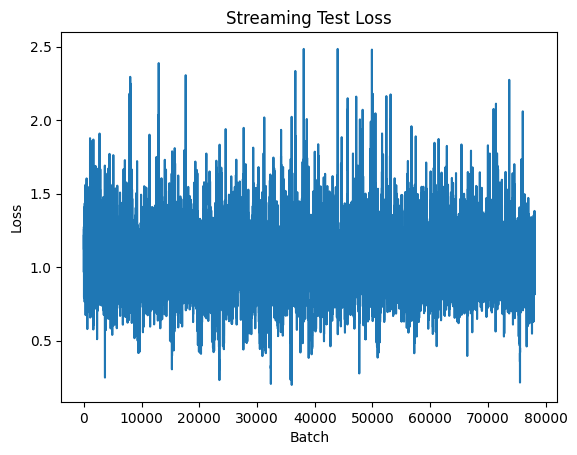

In [27]:
import matplotlib.pyplot as plt

plt.plot(loss)
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.title("Streaming Test Loss")
plt.show()
